In [1]:
import numpy as np
import matplotlib.pyplot as plt

Correlación Close-High: 0.9951


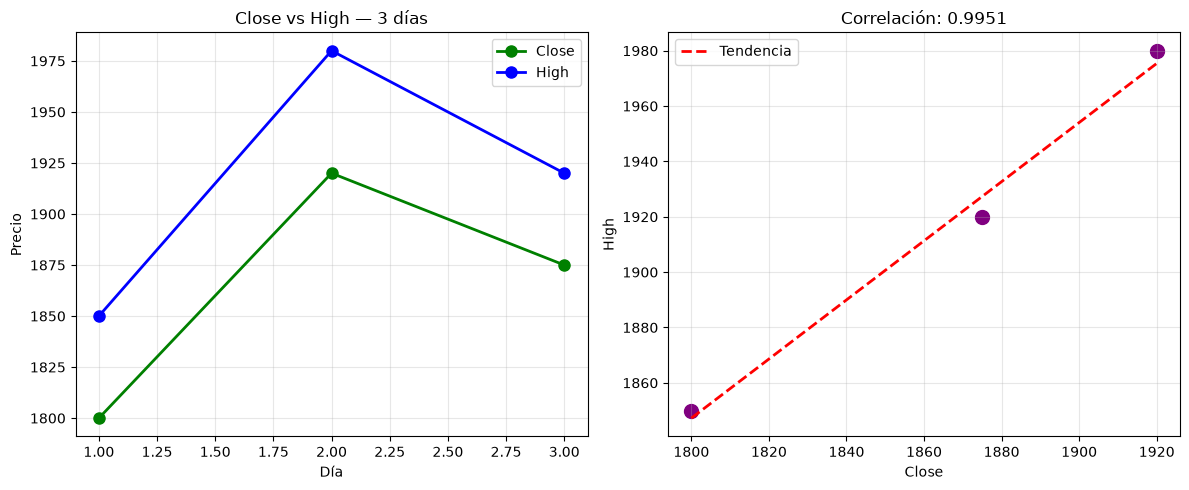

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 3 días de datos simplificados
close = np.array([1800, 1920, 1875])
high  = np.array([1850, 1980, 1920])

# Calcular correlación
correlacion = np.corrcoef(close, high)[0,1]
print(f"Correlación Close-High: {correlacion:.4f}")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1 — Los datos día por día
dias = [1, 2, 3]
axes[0].plot(dias, close, 'go-', linewidth=2, markersize=8, label='Close')
axes[0].plot(dias, high,  'bo-', linewidth=2, markersize=8, label='High')
axes[0].set_title('Close vs High — 3 días')
axes[0].set_xlabel('Día')
axes[0].set_ylabel('Precio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2 — Scatter
axes[1].scatter(close, high, color='purple', s=100)
axes[1].set_title(f'Correlación: {correlacion:.4f}')
axes[1].set_xlabel('Close')
axes[1].set_ylabel('High')
axes[1].grid(True, alpha=0.3)

# Línea de tendencia
z = np.polyfit(close, high, 1)
p = np.poly1d(z)
x_line = np.linspace(close.min(), close.max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label='Tendencia')
axes[1].legend()

plt.tight_layout()
plt.show()

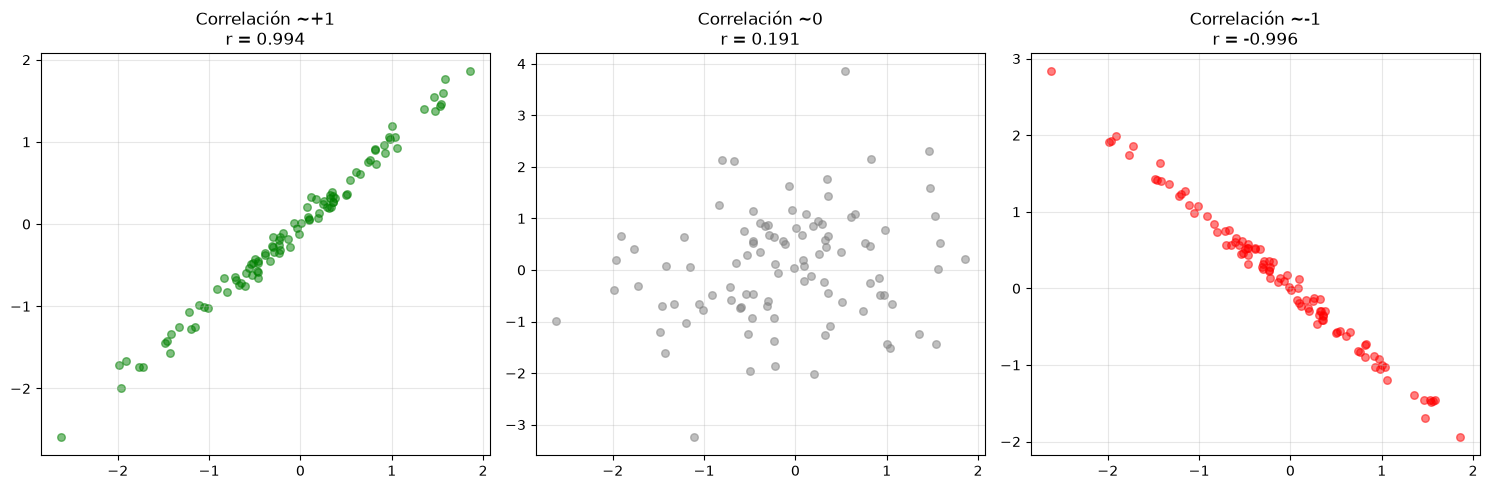

In [3]:
# Los tres casos de correlación en un solo gráfico
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
x = np.random.randn(100)

# Tres casos
y_positiva  =  x + np.random.randn(100) * 0.1   # correlación ~+1
y_cero      =      np.random.randn(100)           # correlación ~0
y_negativa  = -x + np.random.randn(100) * 0.1   # correlación ~-1

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

casos = [
    (x, y_positiva, 'Correlación ~+1', 'green'),
    (x, y_cero,     'Correlación ~0',  'gray'),
    (x, y_negativa, 'Correlación ~-1', 'red'),
]

for i, (xi, yi, titulo, color) in enumerate(casos):
    corr = np.corrcoef(xi, yi)[0,1]
    axes[i].scatter(xi, yi, color=color, alpha=0.5, s=30)
    axes[i].set_title(f'{titulo}\nr = {corr:.3f}')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# Calculando correlación a mano — sin np.corrcoef
close = np.array([1800, 1920, 1875], dtype=float)
high  = np.array([1850, 1980, 1920], dtype=float)

# Paso 1 — medias
media_close = np.mean(close)
media_high  = np.mean(high)
print(f"Media Close: {media_close:.2f}")
print(f"Media High:  {media_high:.2f}")

# Paso 2 — desviaciones del promedio
dev_close = close - media_close
dev_high  = high  - media_high
print(f"\nDesviaciones Close: {dev_close}")
print(f"Desviaciones High:  {dev_high}")

# Paso 3 — numerador (covarianza)
numerador = np.sum(dev_close * dev_high)
print(f"\nNumerador (covarianza): {numerador:.2f}")

# Paso 4 — denominador
denominador = np.sqrt(np.sum(dev_close**2) * np.sum(dev_high**2))
print(f"Denominador: {denominador:.2f}")

# Paso 5 — correlación final
r = numerador / denominador
print(f"\nCorrelación calculada a mano: {r:.4f}")
print(f"Correlación con np.corrcoef:  {np.corrcoef(close, high)[0,1]:.4f}")

Media Close: 1865.00
Media High:  1916.67

Desviaciones Close: [-65.  55.  10.]
Desviaciones High:  [-66.66666667  63.33333333   3.33333333]

Numerador (covarianza): 7850.00
Denominador: 7888.60

Correlación calculada a mano: 0.9951
Correlación con np.corrcoef:  0.9951


In [5]:
# Magnitud de un vector — su "largo"
v = np.array([3, 4])

# A mano: raíz cuadrada de la suma de cuadrados
magnitud_manual = np.sqrt(v[0]**2 + v[1]**2)

# Con NumPy
magnitud_numpy = np.linalg.norm(v)

print(f"Vector: {v}")
print(f"Magnitud manual: {magnitud_manual}")
print(f"Magnitud NumPy:  {magnitud_numpy}")

Vector: [3 4]
Magnitud manual: 5.0
Magnitud NumPy:  5.0


In [6]:
# Producto punto — la operación central de ML
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# A mano
manual = (a[0]*b[0]) + (a[1]*b[1]) + (a[2]*b[2])

# Con NumPy
numpy_dot = np.dot(a, b)

print(f"Vector a: {a}")
print(f"Vector b: {b}")
print(f"Producto punto manual: {manual}")
print(f"Producto punto NumPy:  {numpy_dot}")

# Ahora con tus precios de oro
close  = np.array([1800, 1920, 1875], dtype=float)
pesos  = np.array([0.5,  0.3,  0.2])  # pesos que suman 1

precio_ponderado = np.dot(close, pesos)
print(f"\nPrecio ponderado del oro: {precio_ponderado:.2f}")
print(f"Promedio simple:          {np.mean(close):.2f}")

Vector a: [1 2 3]
Vector b: [4 5 6]
Producto punto manual: 32
Producto punto NumPy:  32

Precio ponderado del oro: 1851.00
Promedio simple:          1865.00


In [7]:
trader_a = np.array([5, 5, 5, 5, 5])
trader_b = np.array([25, -15, 20, -10, 15])

print(f"Promedio A: {np.mean(trader_a):.1f}%")
print(f"Promedio B: {np.mean(trader_b):.1f}%")

print(f"\nVarianza A: {np.var(trader_b):.1f}")
print(f"Varianza B: {np.var(trader_b):.1f}")

print(f"\nDesv. estándar A: {np.std(trader_a):.1f}%")
print(f"Desv. estándar B: {np.std(trader_b):.1f}%")

Promedio A: 5.0%
Promedio B: 7.0%

Varianza A: 266.0
Varianza B: 266.0

Desv. estándar A: 0.0%
Desv. estándar B: 16.3%


In [8]:
trader_a = np.array([5, 5, 5, 5, 5])
trader_b = np.array([25, -15, 20, -10, 15])

print(f"Promedio A: {np.mean(trader_a):.1f}%")
print(f"Promedio B: {np.mean(trader_b):.1f}%")

print(f"\nVarianza A: {np.var(trader_a):.1f}")
print(f"Varianza B: {np.var(trader_b):.1f}")

print(f"\nDesv. estándar A: {np.std(trader_a):.1f}%")
print(f"Desv. estándar B: {np.std(trader_b):.1f}%")

Promedio A: 5.0%
Promedio B: 7.0%

Varianza A: 0.0
Varianza B: 266.0

Desv. estándar A: 0.0%
Desv. estándar B: 16.3%


In [9]:
# Varianza a mano — paso a paso
b = np.array([25, -15, 20, -10, 15], dtype=float)

# Paso 1 — media
media = np.mean(b)
print(f"Media: {media:.1f}%")

# Paso 2 — desviaciones
desviaciones = b - media
print(f"Desviaciones: {desviaciones}")

# Paso 3 — desviaciones al cuadrado
cuadrados = desviaciones ** 2
print(f"Cuadrados: {cuadrados}")

# Paso 4 — promedio de cuadrados = varianza
varianza_manual = np.mean(cuadrados)
print(f"\nVarianza manual:  {varianza_manual:.1f}")
print(f"Varianza NumPy:   {np.var(b):.1f}")

# Paso 5 — raíz cuadrada = desviación estándar
std_manual = np.sqrt(varianza_manual)
print(f"\nDesv. std manual: {std_manual:.1f}%")
print(f"Desv. std NumPy:  {np.std(b):.1f}%")

Media: 7.0%
Desviaciones: [ 18. -22.  13. -17.   8.]
Cuadrados: [324. 484. 169. 289.  64.]

Varianza manual:  266.0
Varianza NumPy:   266.0

Desv. std manual: 16.3%
Desv. std NumPy:  16.3%


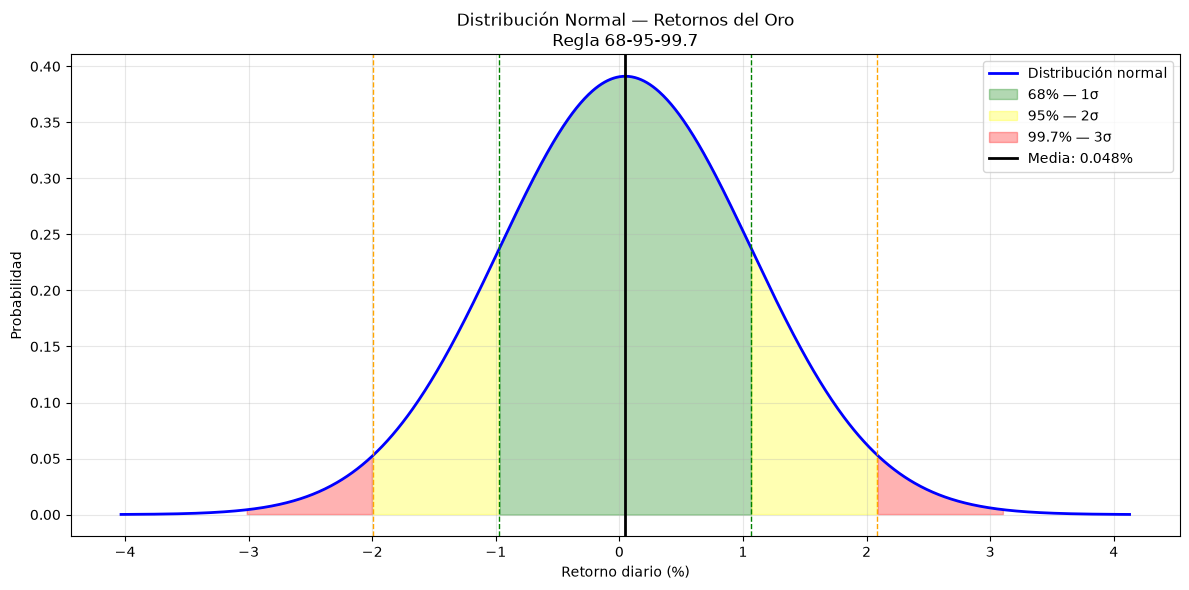

=== REGLA 68-95-99.7 APLICADA AL ORO ===
68% de los días: entre -0.97% y 1.07%
95% de los días: entre -1.99% y 2.09%
99.7% de los días: entre -3.01% y 3.11%

El día +5.95% está a 5.8 desviaciones estándar


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros del oro
mu    = 0.048   # media
sigma = 1.02    # desviación estándar

# Generar la curva normal
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = (1/(sigma * np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x, y, 'b-', linewidth=2, label='Distribución normal')

# Colorear las zonas
ax.fill_between(x, y, where=(x >= mu-sigma) & (x <= mu+sigma),
                alpha=0.3, color='green', label='68% — 1σ')
ax.fill_between(x, y, where=((x >= mu-2*sigma) & (x < mu-sigma)) |
                             ((x > mu+sigma) & (x <= mu+2*sigma)),
                alpha=0.3, color='yellow', label='95% — 2σ')
ax.fill_between(x, y, where=((x >= mu-3*sigma) & (x < mu-2*sigma)) |
                             ((x > mu+2*sigma) & (x <= mu+3*sigma)),
                alpha=0.3, color='red', label='99.7% — 3σ')

# Líneas de referencia
ax.axvline(mu, color='black', linewidth=2, label=f'Media: {mu}%')
ax.axvline(mu+sigma, color='green', linewidth=1, linestyle='--')
ax.axvline(mu-sigma, color='green', linewidth=1, linestyle='--')
ax.axvline(mu+2*sigma, color='orange', linewidth=1, linestyle='--')
ax.axvline(mu-2*sigma, color='orange', linewidth=1, linestyle='--')

ax.set_title('Distribución Normal — Retornos del Oro\nRegla 68-95-99.7')
ax.set_xlabel('Retorno diario (%)')
ax.set_ylabel('Probabilidad')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# La regla aplicada al oro
print("=== REGLA 68-95-99.7 APLICADA AL ORO ===")
print(f"68% de los días: entre {mu-sigma:.2f}% y {mu+sigma:.2f}%")
print(f"95% de los días: entre {mu-2*sigma:.2f}% y {mu+2*sigma:.2f}%")
print(f"99.7% de los días: entre {mu-3*sigma:.2f}% y {mu+3*sigma:.2f}%")
print(f"\nEl día +5.95% está a {(5.95-mu)/sigma:.1f} desviaciones estándar")

In [12]:
import numpy as np
import pandas as pd
import yfinance as yf

# Cargar datos
df = yf.download("GC=F", start="2020-01-01", end="2024-12-31")
df['retorno'] = df['Close'].pct_change() * 100
df = df.dropna()

# Probabilidad simple de que el oro suba
dias_positivos = (df['retorno'] > 0).sum()
total_dias = len(df)
prob_sube = dias_positivos / total_dias

print(f"Total días: {total_dias}")
print(f"Días positivos: {dias_positivos}")
print(f"P(sube) = {prob_sube:.3f} = {prob_sube*100:.1f}%")

# Probabilidad condicional — dado que ayer cayó más de 1%
df['retorno_ayer'] = df['retorno'].shift(1)
df = df.dropna()

# Condición: ayer cayó más de 1%
condicion = df['retorno_ayer'] < -1.0
dias_con_condicion = condicion.sum()

# De esos días, cuántos subió hoy
subio_dado_condicion = ((condicion) & (df['retorno'] > 0)).sum()
prob_condicional = subio_dado_condicion / dias_con_condicion

print(f"\nDías donde ayer cayó >1%: {dias_con_condicion}")
print(f"De esos, días que subió hoy: {subio_dado_condicion}")
print(f"P(sube | ayer cayó >1%) = {prob_condicional:.3f} = {prob_condicional*100:.1f}%")

# Comparación
print(f"\nP(sube) sin condición:     {prob_sube*100:.1f}%")
print(f"P(sube | ayer cayó >1%):   {prob_condicional*100:.1f}%")
print(f"\n¿La caída de ayer cambia la probabilidad de hoy?")

[*********************100%***********************]  1 of 1 completed

Total días: 1256
Días positivos: 685
P(sube) = 0.545 = 54.5%

Días donde ayer cayó >1%: 157
De esos, días que subió hoy: 98
P(sube | ayer cayó >1%) = 0.624 = 62.4%

P(sube) sin condición:     54.5%
P(sube | ayer cayó >1%):   62.4%

¿La caída de ayer cambia la probabilidad de hoy?


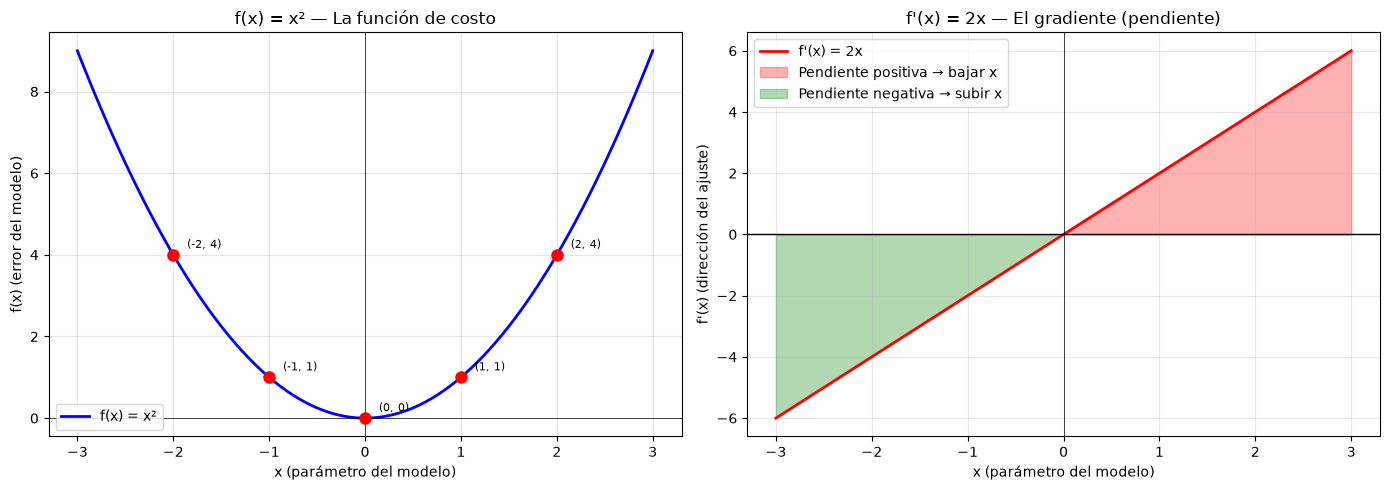

Pendiente en x=-2: -4 → función bajando, mover x hacia la derecha
Pendiente en x=0:  0 → mínimo encontrado, no mover
Pendiente en x=2:  4 → función subiendo, mover x hacia la izquierda


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# La función más simple: f(x) = x²
x = np.linspace(-3, 3, 100)
y = x**2

# Su derivada: f'(x) = 2x
dy = 2*x

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1 — La función
axes[0].plot(x, y, 'b-', linewidth=2, label='f(x) = x²')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].axvline(0, color='black', linewidth=0.5)

# Marcar puntos específicos
puntos = [-2, -1, 0, 1, 2]
for p in puntos:
    axes[0].plot(p, p**2, 'ro', markersize=8)
    axes[0].annotate(f'({p}, {p**2})', (p, p**2),
                    textcoords="offset points", xytext=(10,5), fontsize=8)

axes[0].set_title('f(x) = x² — La función de costo')
axes[0].set_xlabel('x (parámetro del modelo)')
axes[0].set_ylabel('f(x) (error del modelo)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2 — La derivada
axes[1].plot(x, dy, 'r-', linewidth=2, label="f'(x) = 2x")
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].fill_between(x, dy, 0, where=(x>0), alpha=0.3,
                     color='red', label='Pendiente positiva → bajar x')
axes[1].fill_between(x, dy, 0, where=(x<0), alpha=0.3,
                     color='green', label='Pendiente negativa → subir x')
axes[1].set_title("f'(x) = 2x — El gradiente (pendiente)")
axes[1].set_xlabel('x (parámetro del modelo)')
axes[1].set_ylabel("f'(x) (dirección del ajuste)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Pendiente en x=-2:", 2*(-2), "→ función bajando, mover x hacia la derecha")
print("Pendiente en x=0: ", 2*(0),  "→ mínimo encontrado, no mover")
print("Pendiente en x=2: ", 2*(2),  "→ función subiendo, mover x hacia la izquierda")

=== DESCENSO DE GRADIENTE ===
Paso |  x (parámetro) | Error f(x) |  Gradiente
--------------------------------------------------
   1 |       1.200000 |   1.440000 |   6.000000
   2 |       0.480000 |   0.230400 |   2.400000
   3 |       0.192000 |   0.036864 |   0.960000
   4 |       0.076800 |   0.005898 |   0.384000
   5 |       0.030720 |   0.000944 |   0.153600
   6 |       0.012288 |   0.000151 |   0.061440
   7 |       0.004915 |   0.000024 |   0.024576
   8 |       0.001966 |   0.000004 |   0.009830
   9 |       0.000786 |   0.000001 |   0.003932
  10 |       0.000315 |   0.000000 |   0.001573


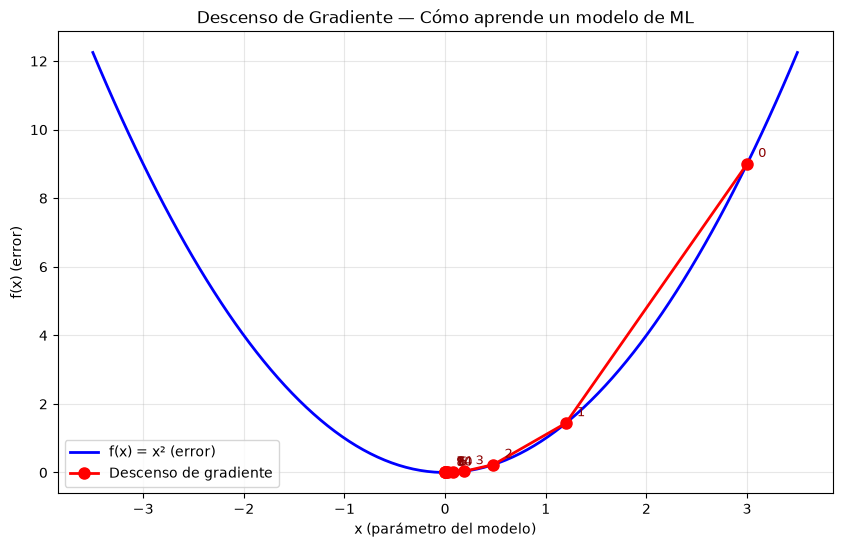

In [14]:
# Descenso de gradiente — simulación paso a paso
# Función de costo: f(x) = x²
# Gradiente: f'(x) = 2x
# Regla de actualización: x_nuevo = x_actual - learning_rate * gradiente

learning_rate = 0.3  # tamaño del paso
x = 3.0              # punto de inicio (parámetro inicial del modelo)

print("=== DESCENSO DE GRADIENTE ===")
print(f"{'Paso':>4} | {'x (parámetro)':>14} | {'Error f(x)':>10} | {'Gradiente':>10}")
print("-" * 50)

pasos_x     = [x]
pasos_error = [x**2]

for paso in range(10):
    gradiente = 2 * x                    # derivada de x²
    x = x - learning_rate * gradiente    # actualizar parámetro
    error = x**2                         # nuevo error
    
    pasos_x.append(x)
    pasos_error.append(error)
    
    print(f"{paso+1:>4} | {x:>14.6f} | {error:>10.6f} | {gradiente:>10.6f}")

# Visualizar el descenso
x_curva = np.linspace(-3.5, 3.5, 100)
y_curva  = x_curva**2

plt.figure(figsize=(10, 6))
plt.plot(x_curva, y_curva, 'b-', linewidth=2, label='f(x) = x² (error)')
plt.plot(pasos_x, pasos_error, 'ro-', markersize=8, linewidth=2, label='Descenso de gradiente')

# Numerar los pasos
for i, (px, pe) in enumerate(zip(pasos_x, pasos_error)):
    plt.annotate(str(i), (px, pe), textcoords="offset points",
                xytext=(8, 5), fontsize=9, color='darkred')

plt.title('Descenso de Gradiente — Cómo aprende un modelo de ML')
plt.xlabel('x (parámetro del modelo)')
plt.ylabel('f(x) (error)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()